# Phase 3: Model Training & Evaluation
## AI-Based Password Strength Prediction System
### Dataset: 3000 passwords | Classes: Weak / Medium / Strong

# Cell 2 — Imports


In [8]:
# All imports needed for Phase 3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import json
import os
import sys

# Add ml/ folder to path so we can import feature_extraction
sys.path.append('.')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier

# Make charts look nice
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_theme(style="whitegrid")

print("All imports successful")

All imports successful


# Cell 3 — Load Dataset


In [3]:
# Load the CSV we generated in Phase 2
df = pd.read_csv("passwords_dataset.csv")

print(f"Shape: {df.shape}")
print(f"\nColumn names:\n{list(df.columns)}")
print(f"\nFirst 5 rows:")
df.head()

Shape: (3000, 14)

Column names:
['length', 'uppercase_count', 'lowercase_count', 'digit_count', 'special_char_count', 'shannon_entropy', 'has_common_pattern', 'has_dictionary_word', 'consecutive_chars', 'char_diversity_ratio', 'keyboard_pattern', 'password', 'label', 'label_name']

First 5 rows:


,length,uppercase_count,lowercase_count,digit_count,special_char_count,shannon_entropy,has_common_pattern,has_dictionary_word,consecutive_chars,char_diversity_ratio,keyboard_pattern,password,label,label_name
0,9,0,6,3,0,3.1699,0,0,1,1.0000,0,7nxp0jf6d,1,Medium
1,10,0,7,3,0,2.9219,0,0,2,0.8000,0,l9fc1xx6cw,1,Medium
2,8,7,1,0,0,2.4056,0,0,2,0.7500,0,WIILpKUI,1,Medium
3,4,0,0,4,0,2.0000,0,0,1,1.0000,0,3408,0,Weak
4,16,7,4,1,4,3.8750,0,0,1,0.9375,0,!c^S&tV9O(sSgUEM,2,Strong


# Cell 4 — Dataset Overview


In [4]:
# Check label distribution
print("Label Distribution:")
print(df["label_name"].value_counts())

# Check for missing values
print(f"\nMissing values: {df.isnull().sum().sum()}")

# Basic stats
print(f"\nBasic Statistics:")
df.describe().round(2)

Label Distribution:
label_name
Medium    1000
Weak      1000
Strong    1000
Name: count, dtype: int64

Missing values: 0

Basic Statistics:


,length,uppercase_count,lowercase_count,digit_count,special_char_count,shannon_entropy,has_common_pattern,has_dictionary_word,consecutive_chars,char_diversity_ratio,keyboard_pattern,label
count,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00
mean,10.26,1.88,5.79,1.72,0.86,2.80,0.05,0.02,1.67,0.82,0.02,1.00
std,4.13,2.62,2.85,2.03,1.17,1.06,0.22,0.13,1.49,0.23,0.14,0.82
min,4.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.12,0.00,0.00
25%,7.00,0.00,4.00,0.00,0.00,2.52,0.00,0.00,1.00,0.80,0.00,0.00
50%,9.00,0.00,6.00,1.00,0.00,3.08,0.00,0.00,1.00,0.89,0.00,1.00
75%,14.00,4.00,8.00,3.00,2.00,3.52,0.00,0.00,2.00,1.00,0.00,2.00
max,20.00,10.00,13.00,10.00,7.00,4.32,1.00,1.00,8.00,1.00,1.00,2.00


# Cell 5 — Visualise Label Distribution


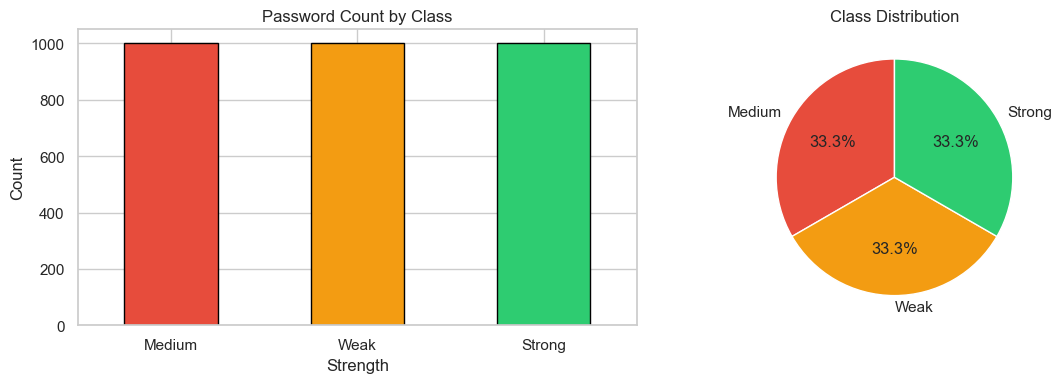

Chart saved


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
colors = ["#e74c3c", "#f39c12", "#2ecc71"]
df["label_name"].value_counts().plot(
    kind="bar",
    ax=axes[0],
    color=colors,
    edgecolor="black"
)
axes[0].set_title("Password Count by Class")
axes[0].set_xlabel("Strength")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis='x', rotation=0)

# Pie chart
df["label_name"].value_counts().plot(
    kind="pie",
    ax=axes[1],
    colors=colors,
    autopct="%1.1f%%",
    startangle=90
)
axes[1].set_title("Class Distribution")
axes[1].set_ylabel("")

plt.tight_layout()
plt.savefig("label_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved")

# Cell 6 — Feature Correlation Heatmap


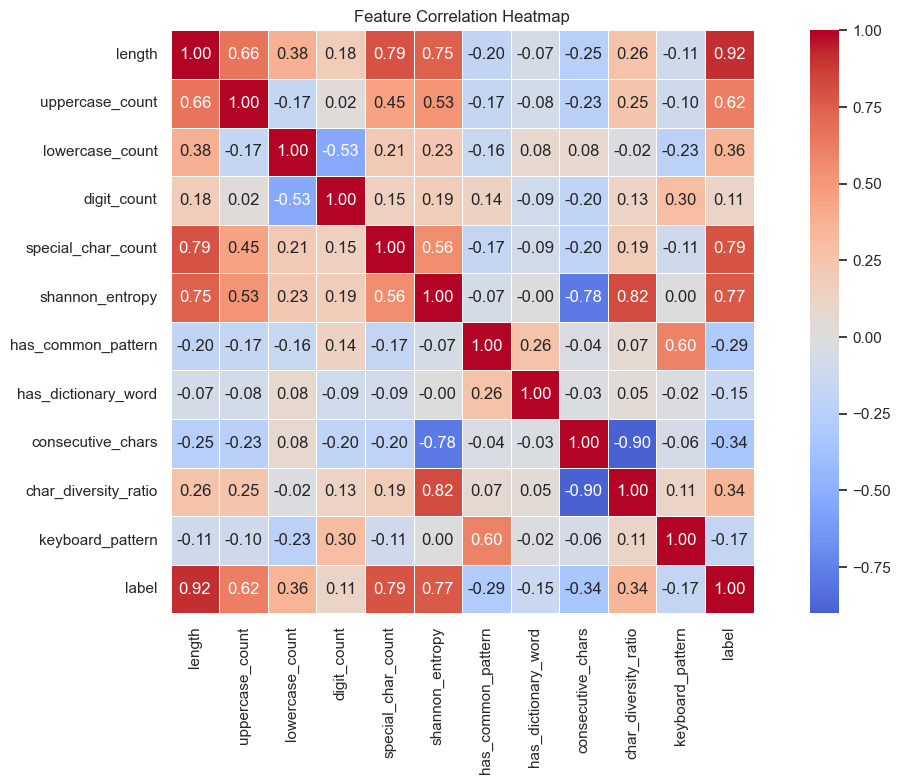

Heatmap saved


In [7]:
FEATURES = [
    "length", "uppercase_count", "lowercase_count",
    "digit_count", "special_char_count", "shannon_entropy",
    "has_common_pattern", "has_dictionary_word",
    "consecutive_chars", "char_diversity_ratio", "keyboard_pattern"
]

plt.figure(figsize=(12, 8))
correlation = df[FEATURES + ["label"]].corr()

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5
)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Heatmap saved")

# Cell 7 — Prepare X and y

In [9]:
X = df[FEATURES]
y = df["label"]

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"\nFeatures used:\n{FEATURES}")
print(f"\nLabel mapping: 0=Weak, 1=Medium, 2=Strong")

X shape: (3000, 11)
y shape: (3000,)

Features used:
['length', 'uppercase_count', 'lowercase_count', 'digit_count', 'special_char_count', 'shannon_entropy', 'has_common_pattern', 'has_dictionary_word', 'consecutive_chars', 'char_diversity_ratio', 'keyboard_pattern']

Label mapping: 0=Weak, 1=Medium, 2=Strong


# Cell 8 — Train/Test Split


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Training samples : {len(X_train)}")
print(f"Testing samples  : {len(X_test)}")
print(f"\nTrain label distribution:")
print(pd.Series(y_train).value_counts().sort_index()
      .rename({0:"Weak", 1:"Medium", 2:"Strong"}))
print(f"\nTest label distribution:")
print(pd.Series(y_test).value_counts().sort_index()
      .rename({0:"Weak", 1:"Medium", 2:"Strong"}))

Training samples : 2400
Testing samples  : 600

Train label distribution:
label
Weak      800
Medium    800
Strong    800
Name: count, dtype: int64

Test label distribution:
label
Weak      200
Medium    200
Strong    200
Name: count, dtype: int64


# Cell 9 — Scale Features


In [11]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Features scaled using StandardScaler")
print(f"Mean of first feature before scaling: {X_train.iloc[:,0].mean():.2f}")
print(f"Mean of first feature after scaling : {X_train_scaled[:,0].mean():.4f}")

Features scaled using StandardScaler
Mean of first feature before scaling: 10.25
Mean of first feature after scaling : 0.0000


# Cell 10 — Define All 5 Models


In [13]:
models = {
    "Decision Tree": DecisionTreeClassifier(
        random_state=42, max_depth=10
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=100, random_state=42
    ),
    "Logistic Regression": LogisticRegression(
        max_iter=1000, random_state=42
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=100, random_state=42
    ),
    "Neural Network": MLPClassifier(
        hidden_layer_sizes=(64, 32),
        max_iter=500,
        random_state=42
    )
}

NEEDS_SCALING = {"Logistic Regression", "Neural Network"}

print("5 models defined")
for name in models:
    scaled = "uses scaling" if name in NEEDS_SCALING else "no scaling"
    print(f"  • {name} ({scaled})")

5 models defined
  • Decision Tree (no scaling)
  • Random Forest (no scaling)
  • Logistic Regression (uses scaling)
  • Gradient Boosting (no scaling)
  • Neural Network (uses scaling)


# Cell 11 — Train All Models


In [14]:
results = {}
trained_models = {}
all_predictions = {}

print("Training models...\n")

for name, model in models.items():
    print(f"⏳ Training {name}...")

    if name in NEEDS_SCALING:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    trained_models[name] = model
    all_predictions[name] = y_pred

    print(f"{name}: {acc * 100:.2f}%\n")

print("=" * 40)
print("All models trained!")

Training models...

⏳ Training Decision Tree...
Decision Tree: 99.83%

⏳ Training Random Forest...
Random Forest: 99.67%

⏳ Training Logistic Regression...
Logistic Regression: 99.33%

⏳ Training Gradient Boosting...
Gradient Boosting: 99.67%

⏳ Training Neural Network...
Neural Network: 99.67%

All models trained!


# Cell 12 — Model Comparison Chart


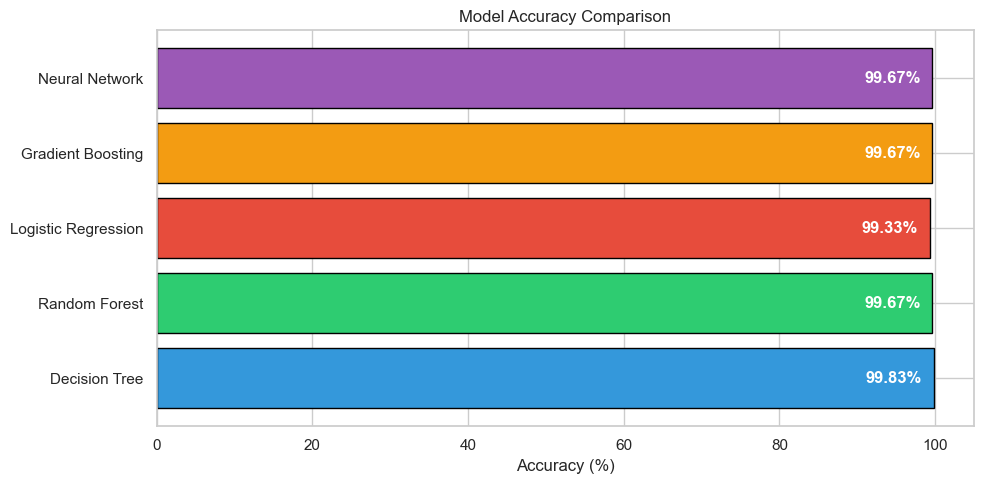

In [15]:
names = list(results.keys())
accuracies = [results[n] * 100 for n in names]

colors = ["#3498db", "#2ecc71", "#e74c3c", "#f39c12", "#9b59b6"]

plt.figure(figsize=(10, 5))
bars = plt.barh(names, accuracies, color=colors, edgecolor="black")

# Add accuracy labels on bars
for bar, acc in zip(bars, accuracies):
    plt.text(
        bar.get_width() - 1.5,
        bar.get_y() + bar.get_height() / 2,
        f"{acc:.2f}%",
        va="center", ha="right",
        color="white", fontweight="bold"
    )

plt.xlabel("Accuracy (%)")
plt.title("Model Accuracy Comparison")
plt.xlim(0, 105)
plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

# Cell 13 — Confusion Matrices for All Models


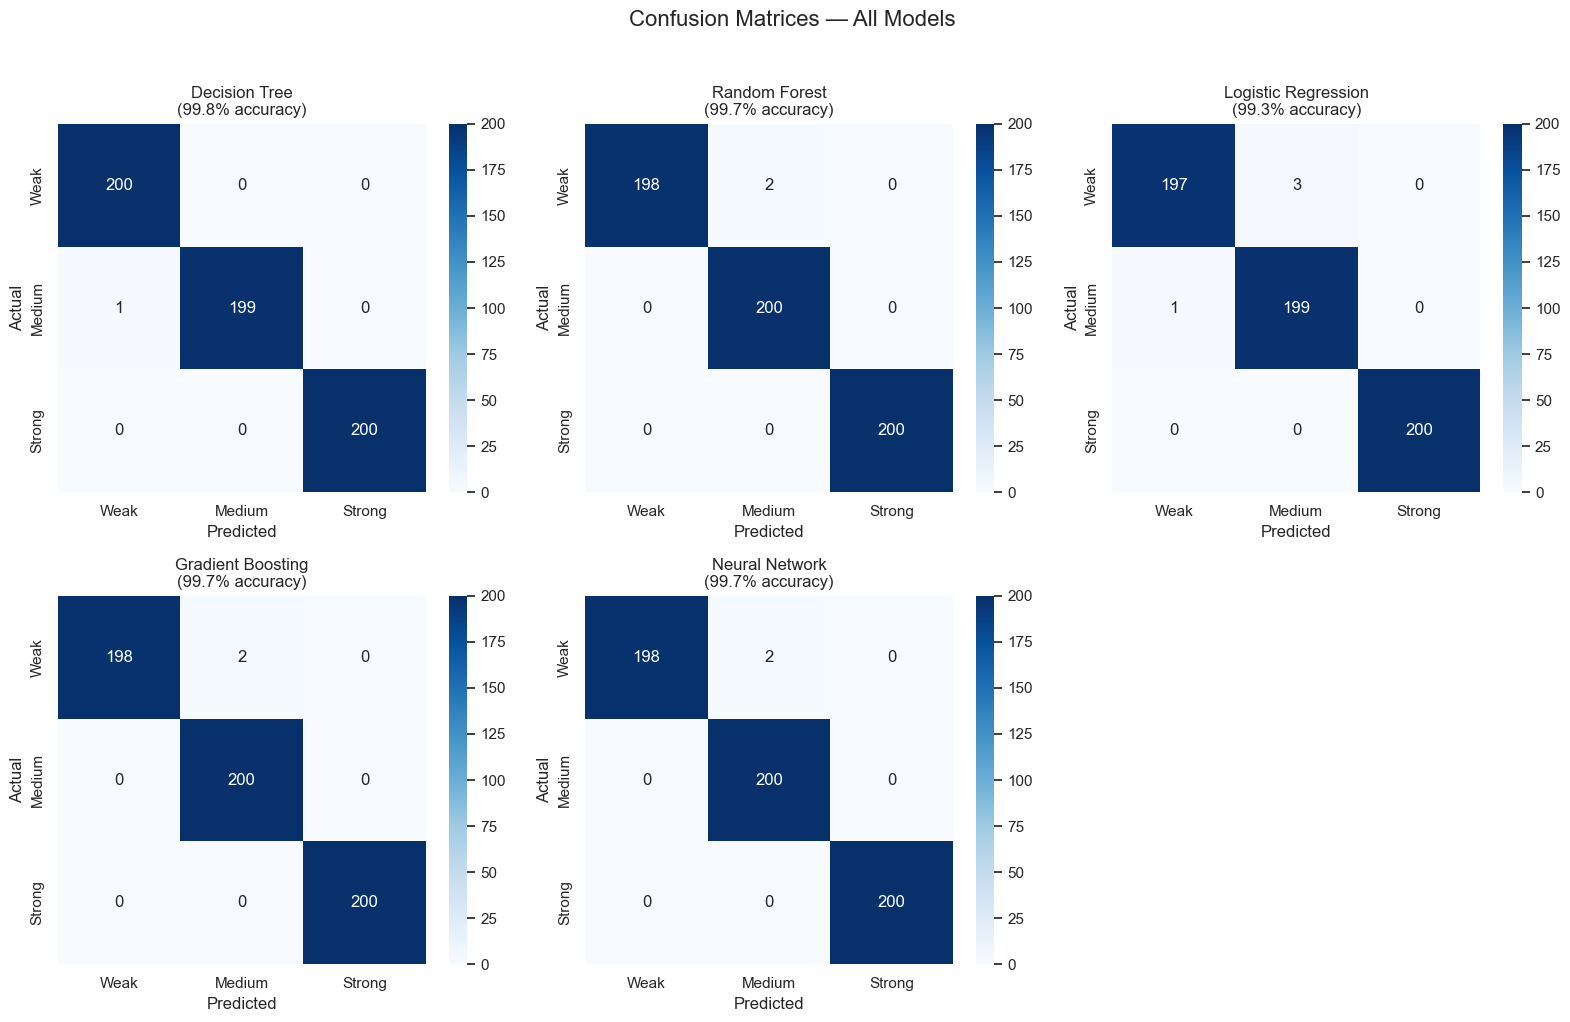

Confusion matrices saved


In [16]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()
class_names = ["Weak", "Medium", "Strong"]

for idx, (name, y_pred) in enumerate(all_predictions.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names,
        ax=axes[idx]
    )
    acc = results[name] * 100
    axes[idx].set_title(f"{name}\n({acc:.1f}% accuracy)")
    axes[idx].set_xlabel("Predicted")
    axes[idx].set_ylabel("Actual")

# Hide the 6th empty subplot
axes[5].set_visible(False)

plt.suptitle("Confusion Matrices — All Models", fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()
print("Confusion matrices saved")

# Cell 14 — Detailed Classification Report


In [17]:
# Print full report for each model
for name, y_pred in all_predictions.items():
    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(classification_report(
        y_test, y_pred,
        target_names=class_names,
        digits=3
    ))


  Decision Tree
              precision    recall  f1-score   support

        Weak      0.995     1.000     0.998       200
      Medium      1.000     0.995     0.997       200
      Strong      1.000     1.000     1.000       200

    accuracy                          0.998       600
   macro avg      0.998     0.998     0.998       600
weighted avg      0.998     0.998     0.998       600


  Random Forest
              precision    recall  f1-score   support

        Weak      1.000     0.990     0.995       200
      Medium      0.990     1.000     0.995       200
      Strong      1.000     1.000     1.000       200

    accuracy                          0.997       600
   macro avg      0.997     0.997     0.997       600
weighted avg      0.997     0.997     0.997       600


  Logistic Regression
              precision    recall  f1-score   support

        Weak      0.995     0.985     0.990       200
      Medium      0.985     0.995     0.990       200
      Strong      

# Cell 15 — Feature Importance (Random Forest)


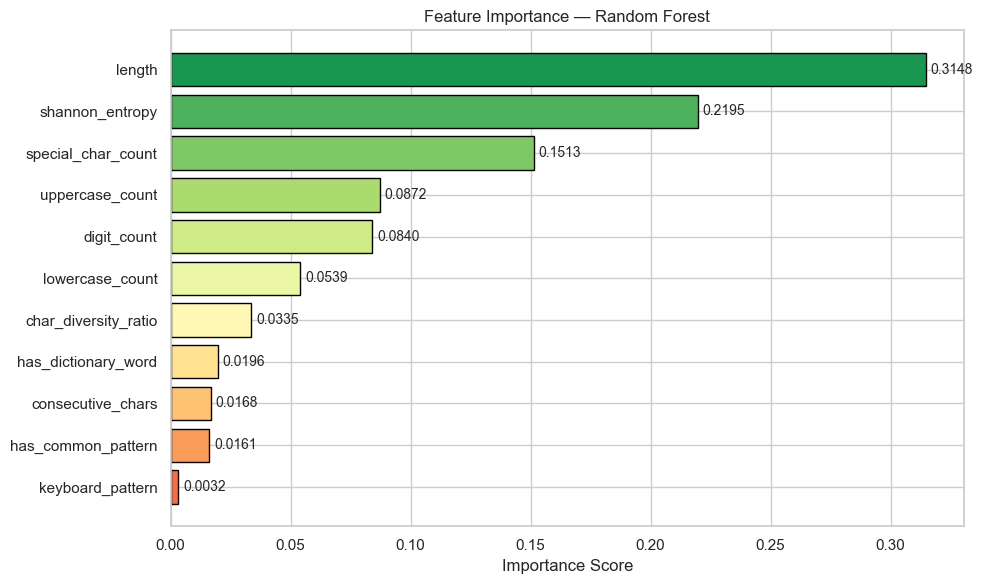

Feature importance chart saved


In [18]:
rf_model = trained_models["Random Forest"]
importances = rf_model.feature_importances_

importance_df = pd.DataFrame({
    "Feature": FEATURES,
    "Importance": importances
}).sort_values("Importance", ascending=True)

plt.figure(figsize=(10, 6))
colors = plt.cm.RdYlGn(
    np.linspace(0.2, 0.9, len(importance_df))
)
bars = plt.barh(
    importance_df["Feature"],
    importance_df["Importance"],
    color=colors,
    edgecolor="black"
)

for bar, val in zip(bars, importance_df["Importance"]):
    plt.text(
        bar.get_width() + 0.002,
        bar.get_y() + bar.get_height() / 2,
        f"{val:.4f}",
        va="center", fontsize=10
    )

plt.xlabel("Importance Score")
plt.title("Feature Importance — Random Forest")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print("Feature importance chart saved")

# Cell 16 — Save Best Model


In [19]:
# Find best model
best_name = max(results, key=results.get)
best_acc  = results[best_name]

print(f" Best Model: {best_name}")
print(f"   Accuracy  : {best_acc * 100:.2f}%")

# Create models/ folder
os.makedirs("models", exist_ok=True)

# Save best model
best_model = trained_models[best_name]
with open("models/best_model.pkl", "wb") as f:
    pickle.dump(best_model, f)

# Save scaler
with open("models/scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

# Save all model results to CSV
results_df = pd.DataFrame(
    list(results.items()),
    columns=["Model", "Accuracy"]
).sort_values("Accuracy", ascending=False)
results_df.to_csv("models/model_results.csv", index=False)

# Save metadata JSON (backend will read this)
metadata = {
    "best_model_name": best_name,
    "best_accuracy":   round(best_acc, 4),
    "needs_scaling":   best_name in NEEDS_SCALING,
    "features":        FEATURES,
    "all_results":     {k: round(v, 4) for k, v in results.items()}
}
with open("models/metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print("\n Saved to models/")
print("   • best_model.pkl")
print("   • scaler.pkl")
print("   • model_results.csv")
print("   • metadata.json")
print(f"\nModel results:")
print(results_df.to_string(index=False))

 Best Model: Decision Tree
   Accuracy  : 99.83%

 Saved to models/
   • best_model.pkl
   • scaler.pkl
   • model_results.csv
   • metadata.json

Model results:
              Model  Accuracy
      Decision Tree  0.998333
      Random Forest  0.996667
  Gradient Boosting  0.996667
     Neural Network  0.996667
Logistic Regression  0.993333


# Cell 17 — Final Summary (Markdown)


## Phase 3 Complete

### What we did:
- Loaded 3000 passwords from `passwords_dataset.csv`
- Engineered 11 features per password
- Split data 80/20 into train/test
- Trained 5 ML models: Decision Tree, Random Forest, Logistic Regression, Gradient Boosting, Neural Network
- Evaluated each with accuracy score, classification report, and confusion matrix
- Visualised feature importance
- Saved best model to `models/best_model.pkl`
